# quiz 1


檢查Movie Reviews資料集

In [136]:
import pandas as pd
from pathlib import Path
from collections import Counter
from PIL import Image
import hashlib

In [137]:
df = pd.read_csv("dataset/Movie Reviews/IMDB Dataset.csv")

print(df.shape)
print(df.columns)

print(df["sentiment"].value_counts())
print(df.isna().sum())

(50000, 2)
Index(['review', 'sentiment'], dtype='str')
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
review       0
sentiment    0
dtype: int64


In [138]:
print("空白影評：", df["review"].str.strip().eq("").sum())
print("重複影評：", df.duplicated(subset=["review"]).sum())

label_counts = df.groupby("review")["sentiment"].nunique()
print("有不同label的影評數：", (label_counts > 1).sum())

空白影評： 0
重複影評： 418
有不同label的影評數： 0


In [139]:
df_clean = df.drop_duplicates(subset=["review"]).reset_index(drop=True)

print(df_clean.shape)
print(df_clean["sentiment"].value_counts())

(49582, 2)
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


檢查Rock-Paper-Scissors Images資料集

In [140]:
data_dir = Path("./dataset/Rock-Paper-Scissors Images")

for label in ["rock", "paper", "scissors"]:
    folder = data_dir / label

    images = [
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    print(label, len(images))

rock 726
paper 712
scissors 750


In [141]:
sizes = Counter()
modes = Counter()

for label in ["rock", "paper", "scissors"]:
    for p in (data_dir / label).iterdir():
        if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            with Image.open(p) as img:
                sizes[img.size] += 1
                modes[img.mode] += 1

print("尺寸：", sizes)
print("色彩模式：", modes)

尺寸： Counter({(300, 200): 2188})
色彩模式： Counter({'RGB': 2188})


檢查Filckr 8k Dataset資料集

In [142]:
flickr_dir = Path("./dataset/Flickr 8k Dataset")
image_dir = flickr_dir / "Images"

captions = pd.read_csv(flickr_dir / "captions.txt")

print(captions.shape)
print(captions.columns)
print(captions.head(5))

(40455, 2)
Index(['image', 'caption'], dtype='str')
                       image  \
0  1000268201_693b08cb0e.jpg   
1  1000268201_693b08cb0e.jpg   
2  1000268201_693b08cb0e.jpg   
3  1000268201_693b08cb0e.jpg   
4  1000268201_693b08cb0e.jpg   

                                             caption  
0  A child in a pink dress is climbing up a set o...  
1              A girl going into a wooden building .  
2   A little girl climbing into a wooden playhouse .  
3  A little girl climbing the stairs to her playh...  
4  A little girl in a pink dress going into a woo...  


In [143]:
print("不同圖片數：", captions["image"].nunique())

caption_counts = captions.groupby("image").size()
print("每張圖片的caption數量分布：")
print(caption_counts.value_counts())

不同圖片數： 8091
每張圖片的caption數量分布：
5    8091
Name: count, dtype: int64


In [144]:
actual_images = {
    p.name for p in image_dir.iterdir()
    if p.is_file() and p.suffix.lower() in [".jpg", ".jpeg", ".png"]
}

caption_images = set(captions["image"])

missing_images = caption_images - actual_images
missing_captions = actual_images - caption_images

print("有caption，但找不到圖片：", len(missing_images))
print("有圖片，但沒有caption：", len(missing_captions))

有caption，但找不到圖片： 0
有圖片，但沒有caption： 0


In [145]:
bad_images = []
sizes = Counter()
modes = Counter()

for filename in sorted(actual_images):
    p = image_dir / filename

    try:
        with Image.open(p) as img:
            img.load()
            sizes[img.size] += 1
            modes[img.mode] += 1
    except OSError:
        bad_images.append(p)

print("無法讀取的圖片數：", len(bad_images))
print("尺寸種類數：", len(sizes))
print("色彩模式：", modes)

無法讀取的圖片數： 0
尺寸種類數： 597
色彩模式： Counter({'RGB': 8091})


In [146]:
duplicate_pairs = captions.duplicated(
    subset=["image", "caption"]
).sum()

print("額外重複的image-caption配對：", duplicate_pairs)

額外重複的image-caption配對： 10


In [147]:
repeated_rows = captions[
    captions.duplicated(subset=["image", "caption"], keep=False)
]

print(repeated_rows.sort_values("image").to_string(index=False))

                    image                                                      caption
2305437797_e6c3460190.jpg                   A dog swimming with a stick in its mouth .
2305437797_e6c3460190.jpg                   A dog swimming with a stick in its mouth .
2335619125_2e2034f2c3.jpg                    A black dog is running through the snow .
2335619125_2e2034f2c3.jpg                    A black dog is running through the snow .
2441629086_52f68eb316.jpg                                 A girl peers into a window .
2441629086_52f68eb316.jpg                                 A girl peers into a window .
2737729252_b3fd9c05b1.jpg       A girl is taking a picture of another girl in a park .
2737729252_b3fd9c05b1.jpg       A girl is taking a picture of another girl in a park .
3262075846_5695021d84.jpg                           A group of men are playing rugby .
3262075846_5695021d84.jpg                           A group of men are playing rugby .
3337046794_296bd2c7e0.jpg                  

In [148]:
seen = {}
duplicate_images = []

for filename in sorted(actual_images):
    p = image_dir / filename

    with Image.open(p) as img:
        content = str(img.size).encode() + img.tobytes()

    fingerprint = hashlib.sha256(content).hexdigest()

    if fingerprint in seen:
        duplicate_images.append((seen[fingerprint], filename))
    else:
        seen[fingerprint] = filename

print("額外重複圖片數：", len(duplicate_images))

for first, repeated in duplicate_images[:5]:
    print(first, "與", repeated)

額外重複圖片數： 1
2851198725_37b6027625.jpg 與 3050606344_af711c726c.jpg


# quiz 2 基礎


In [149]:
import torch
import importlib
from torch import nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from other_code import quiz2
importlib.reload(quiz2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [150]:
train_df, remaining_df = train_test_split(df_clean, test_size=0.2, stratify=df_clean["sentiment"], random_state=42)
val_df, test_df = train_test_split(remaining_df, test_size=0.5, stratify=remaining_df["sentiment"], random_state=42)

In [151]:
vocab = quiz2.build_vocab(train_df["review"])

print("Vocabulary 大小：", len(vocab))
print(list(vocab.items())[:10])

Vocabulary 大小： 20000
[('<PAD>', 0), ('<UNK>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('in', 8), ('it', 9)]


In [152]:
Batch_size = 32

train_dataset = quiz2.ReviewDataset(train_df, vocab)
val_dataset = quiz2.ReviewDataset(val_df, vocab)
test_dataset = quiz2.ReviewDataset(test_df, vocab)

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True, collate_fn=quiz2.collate_reviews)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False, collate_fn=quiz2.collate_reviews)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False,collate_fn=quiz2.collate_reviews)

Epoch 1 | train loss 0.6307, acc 0.6451 | val loss 0.5911, acc 0.6971
Epoch 2 | train loss 0.5177, acc 0.7625 | val loss 0.5292, acc 0.7398
Epoch 3 | train loss 0.4393, acc 0.8100 | val loss 0.4480, acc 0.8163
Epoch 4 | train loss 0.3862, acc 0.8394 | val loss 0.4435, acc 0.8054
Epoch 5 | train loss 0.3580, acc 0.8536 | val loss 0.4526, acc 0.7991
Epoch 6 | train loss 0.3163, acc 0.8752 | val loss 0.4657, acc 0.7979
Epoch 7 | train loss 0.2879, acc 0.8892 | val loss 0.4852, acc 0.8044
Validation loss 連續 3 輪沒有改善，停止訓練。


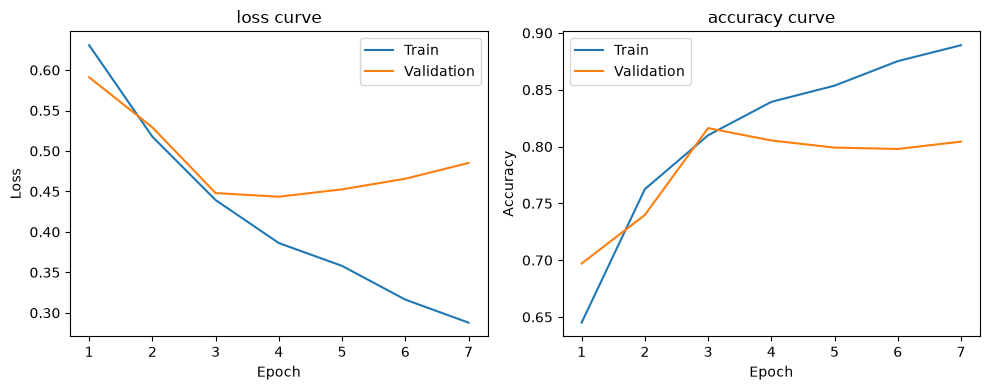

In [153]:
Learning_rate = 0.001
Epochs = 20

model = quiz2.RNNClassifier(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_rate)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz2.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = quiz2.evaluate(model, val_loader, criterion, device)
    

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "./checkpoints/rnn_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break

quiz2.plot_history(history, result_path="./results/rnn")

Test loss：0.4369
Test accuracy：0.8082
Test macro-F1：0.8077


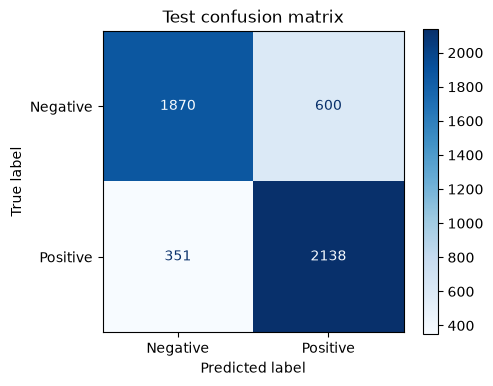

In [154]:
model.load_state_dict(torch.load("./checkpoints/rnn_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, cm = quiz2.evaluate(model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz2.plot_confusion_matrix(cm, result_path="results/rnn")

# quiz 2 進階

Epoch 1 | train loss 0.5364, acc 0.7332 | val loss 0.4471, acc 0.8098
Epoch 2 | train loss 0.3480, acc 0.8579 | val loss 0.3342, acc 0.8663
Epoch 3 | train loss 0.2535, acc 0.9020 | val loss 0.2827, acc 0.8873
Epoch 4 | train loss 0.1905, acc 0.9300 | val loss 0.3106, acc 0.8973
Epoch 5 | train loss 0.1431, acc 0.9477 | val loss 0.3228, acc 0.8868
Epoch 6 | train loss 0.1006, acc 0.9657 | val loss 0.3730, acc 0.8856
Validation loss 連續 3 輪沒有改善，停止訓練。


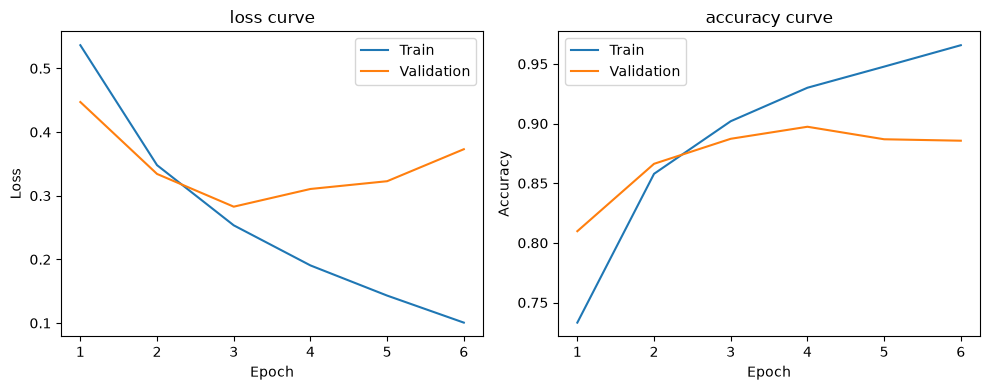

In [155]:
model = quiz2.LSTMClassifier(vocab_size=len(vocab)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_rate)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz2.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = quiz2.evaluate(model, val_loader, criterion, device)
    

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "./checkpoints/lstm_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break

quiz2.plot_history(history, result_path="./results/lstm")

Test loss：0.2821
Test accuracy：0.8897
Test macro-F1：0.8897


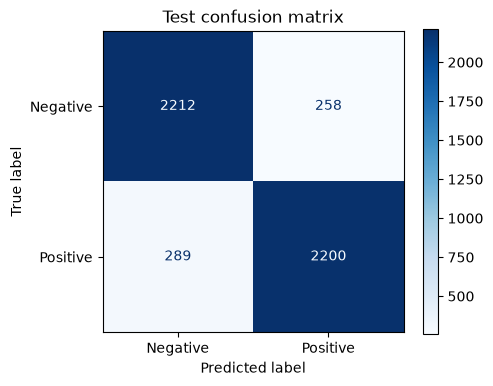

In [156]:
model.load_state_dict(torch.load("./checkpoints/lstm_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, cm = quiz2.evaluate(model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz2.plot_confusion_matrix(cm, result_path="results/lstm")

# quiz 3 基礎

In [157]:
import importlib
from PIL import Image
from torch.utils.data import DataLoader
from other_code import quiz3

importlib.reload(quiz3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [158]:
train_samples, val_samples, test_samples, class_to_idx = (quiz3.prepare_splits("./dataset/Rock-Paper-Scissors Images"))

for name, samples in [
    ("train", train_samples),
    ("validation", val_samples),
    ("test", test_samples)
]:
    print(name, len(samples))

print("類別對照：", class_to_idx)

train 1750
validation 219
test 219
類別對照： {'rock': 0, 'paper': 1, 'scissors': 2}


In [159]:
Batch_size = 32

vit_model, vit_train_transform, vit_eval_transform = quiz3.create_vit()

train_dataset = quiz3.ImageDataset(train_samples, vit_train_transform)
val_dataset = quiz3.ImageDataset(val_samples, vit_eval_transform)
test_dataset = quiz3.ImageDataset(test_samples, vit_eval_transform)

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)

Epoch 1 | train loss 0.4575, acc 0.8491 | val loss 0.1666, acc 0.9726
Epoch 2 | train loss 0.1423, acc 0.9737 | val loss 0.0951, acc 0.9863
Epoch 3 | train loss 0.0888, acc 0.9863 | val loss 0.0717, acc 0.9954
Epoch 4 | train loss 0.0662, acc 0.9897 | val loss 0.0592, acc 0.9954
Epoch 5 | train loss 0.0487, acc 0.9943 | val loss 0.0482, acc 0.9954
Epoch 6 | train loss 0.0414, acc 0.9937 | val loss 0.0419, acc 0.9954
Epoch 7 | train loss 0.0368, acc 0.9943 | val loss 0.0430, acc 0.9954
Epoch 8 | train loss 0.0316, acc 0.9954 | val loss 0.0333, acc 1.0000
Epoch 9 | train loss 0.0281, acc 0.9977 | val loss 0.0301, acc 1.0000
Epoch 10 | train loss 0.0223, acc 0.9994 | val loss 0.0279, acc 0.9954
Epoch 11 | train loss 0.0259, acc 0.9949 | val loss 0.0247, acc 1.0000
Epoch 12 | train loss 0.0213, acc 0.9960 | val loss 0.0241, acc 1.0000
Epoch 13 | train loss 0.0191, acc 0.9983 | val loss 0.0239, acc 1.0000
Epoch 14 | train loss 0.0174, acc 0.9983 | val loss 0.0244, acc 1.0000
Epoch 15 | trai

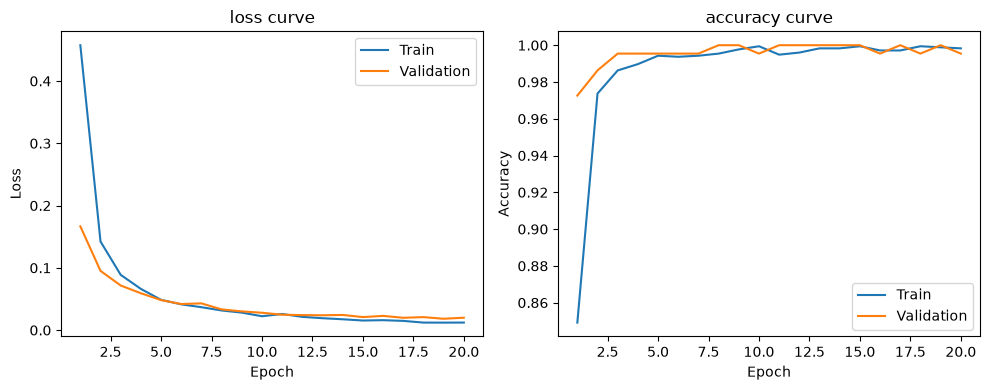

In [160]:
Learning_rate = 0.001
Weight_decay = 0.01
Epochs = 20

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(vit_model.head.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

vit_model = vit_model.to(device)
for parameter in vit_model.parameters():
    parameter.requires_grad = False

for parameter in vit_model.head.parameters():
    parameter.requires_grad = True

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz3.train_one_epoch(vit_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _, _ = quiz3.evaluate(vit_model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(vit_model.state_dict(), "./checkpoints/vit_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break
    
quiz3.plot_history(history, result_path="./results/vit")

Test loss：0.0158
Test accuracy：0.9954
Test macro-F1：0.9955


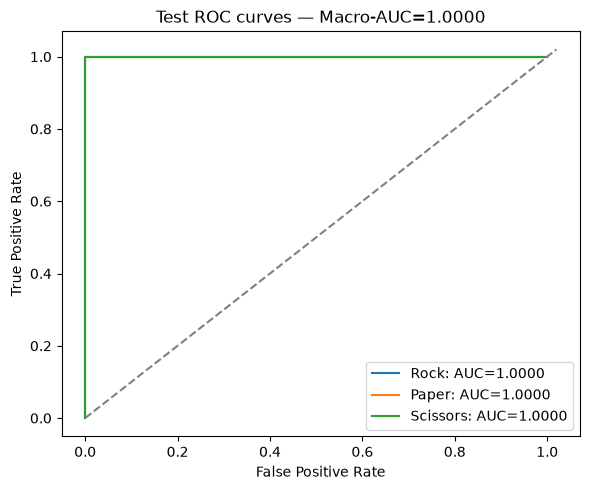

In [161]:
vit_model.load_state_dict(torch.load("./checkpoints/vit_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, test_auc, y_true, y_prob = quiz3.evaluate(vit_model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz3.plot_roc(y_true, y_prob, result_path="./results/vit")

# quiz 3 進階

In [162]:
resnet_model, resnet_train_transform, resnet_eval_transform = (quiz3.create_resnet())

train_dataset = quiz3.ImageDataset(train_samples, resnet_train_transform)
val_dataset = quiz3.ImageDataset(val_samples, resnet_eval_transform)
test_dataset = quiz3.ImageDataset(test_samples, resnet_eval_transform)

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False, num_workers=0)

Epoch 1 | train loss 0.8646, acc 0.7840 | val loss 0.6720, acc 0.9269
Epoch 2 | train loss 0.5431, acc 0.9394 | val loss 0.4548, acc 0.9452
Epoch 3 | train loss 0.3879, acc 0.9589 | val loss 0.3362, acc 0.9680
Epoch 4 | train loss 0.3041, acc 0.9651 | val loss 0.2704, acc 0.9726
Epoch 5 | train loss 0.2511, acc 0.9714 | val loss 0.2238, acc 0.9772
Epoch 6 | train loss 0.2128, acc 0.9783 | val loss 0.1923, acc 0.9863
Epoch 7 | train loss 0.1837, acc 0.9789 | val loss 0.1716, acc 0.9817
Epoch 8 | train loss 0.1591, acc 0.9800 | val loss 0.1526, acc 0.9817
Epoch 9 | train loss 0.1434, acc 0.9800 | val loss 0.1397, acc 0.9863
Epoch 10 | train loss 0.1278, acc 0.9886 | val loss 0.1299, acc 0.9863
Epoch 11 | train loss 0.1174, acc 0.9851 | val loss 0.1163, acc 0.9863
Epoch 12 | train loss 0.1058, acc 0.9857 | val loss 0.1072, acc 0.9863
Epoch 13 | train loss 0.1006, acc 0.9874 | val loss 0.1018, acc 0.9863
Epoch 14 | train loss 0.0893, acc 0.9909 | val loss 0.0969, acc 0.9863
Epoch 15 | trai

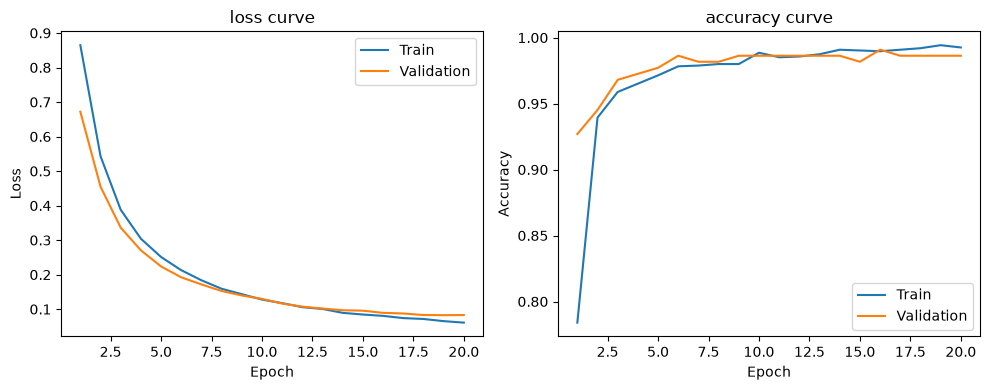

In [163]:
Learning_rate = 0.001
Weight_decay = 0.01
Epochs = 20

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(resnet_model.fc.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

resnet_model = resnet_model.to(device)
for parameter in resnet_model.parameters():
    parameter.requires_grad = False

for parameter in resnet_model.fc.parameters():
    parameter.requires_grad = True
    
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz3.train_one_epoch(resnet_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _, _ = quiz3.evaluate(resnet_model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        torch.save(resnet_model.state_dict(), "./checkpoints/resnet_best.pt")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Validation loss 連續 3 輪沒有改善，停止訓練。")
        break
    
quiz3.plot_history(history, result_path="./results/resnet")

Test loss：0.0801
Test accuracy：0.9726
Test macro-F1：0.9725


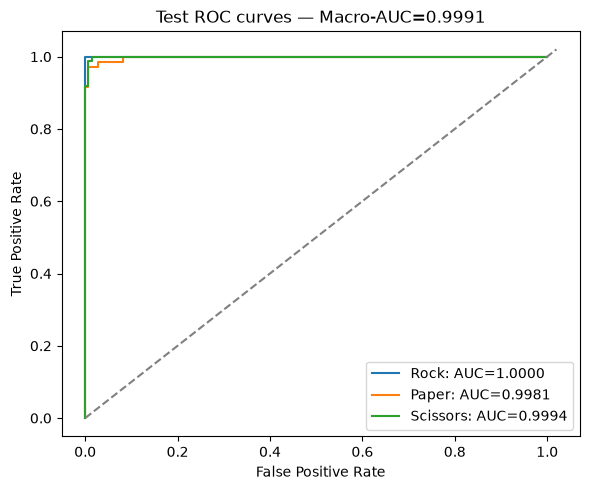

In [164]:
resnet_model.load_state_dict(torch.load("./checkpoints/resnet_best.pt", map_location=device, weights_only=True))
test_loss, test_acc, test_f1, test_auc, y_true, y_prob = quiz3.evaluate(resnet_model, test_loader, criterion, device)

print(f"Test loss：{test_loss:.4f}")
print(f"Test accuracy：{test_acc:.4f}")
print(f"Test macro-F1：{test_f1:.4f}")
quiz3.plot_roc(y_true, y_prob, result_path="./results/resnet")

# quiz 4 基礎

In [165]:
import torch
import importlib
from torch.utils.data import DataLoader
from pathlib import Path
from other_code import quiz4

importlib.reload(quiz4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [166]:
train_df, val_df, test_df = quiz4.prepare_splits("./dataset/Flickr 8k Dataset/captions.txt")

for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df)
]:
    print(
        name,
        "圖片檔名數：", df["image"].nunique(),
        "Caption筆數：", len(df)
    )

train 圖片檔名數： 6473 Caption筆數： 32365
validation 圖片檔名數： 809 Caption筆數： 4045
test 圖片檔名數： 809 Caption筆數： 4045


In [167]:
vocab = quiz4.build_vocab(train_df["caption"])

print("Vocabulary 大小：", len(vocab))
print(list(vocab.items())[:10])

Vocabulary 大小： 7688
[('<PAD>', 0), ('<UNK>', 1), ('<BOS>', 2), ('<EOS>', 3), ('a', 4), ('in', 5), ('the', 6), ('on', 7), ('is', 8), ('and', 9)]


In [168]:
Batch_size = 32
image_dir = "./dataset/Flickr 8k Dataset/Images"

transform = quiz4.create_transform()

train_dataset = quiz4.CaptionDataset(train_df, image_dir, vocab, transform)
val_dataset = quiz4.CaptionDataset(val_df, image_dir, vocab, transform)
test_dataset = quiz4.CaptionDataset(test_df, image_dir, vocab, transform)

train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True, collate_fn=quiz4.collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False, collate_fn=quiz4.collate_fn, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False, collate_fn=quiz4.collate_fn, num_workers=0)

Epoch 1 | train loss 4.0737, token acc 0.3016 | val loss 3.5038, token acc 0.3503
已保存最佳模型
Epoch 2 | train loss 3.3507, token acc 0.3571 | val loss 3.2645, token acc 0.3730
已保存最佳模型
Epoch 3 | train loss 3.1018, token acc 0.3761 | val loss 3.1645, token acc 0.3840
已保存最佳模型
Epoch 4 | train loss 2.9457, token acc 0.3879 | val loss 3.1212, token acc 0.3896
已保存最佳模型
Epoch 5 | train loss 2.8253, token acc 0.3981 | val loss 3.1006, token acc 0.3941
已保存最佳模型
Epoch 6 | train loss 2.7323, token acc 0.4049 | val loss 3.0860, token acc 0.3959
已保存最佳模型
Epoch 7 | train loss 2.6547, token acc 0.4120 | val loss 3.0948, token acc 0.3977
Epoch 8 | train loss 2.5885, token acc 0.4179 | val loss 3.0963, token acc 0.4000
Epoch 9 | train loss 2.5314, token acc 0.4237 | val loss 3.1014, token acc 0.3998
Epoch 10 | train loss 2.4828, token acc 0.4294 | val loss 3.1148, token acc 0.4011
Epoch 11 | train loss 2.4342, token acc 0.4348 | val loss 3.1289, token acc 0.4033
Validation loss 連續 5 輪沒有改善，停止訓練。


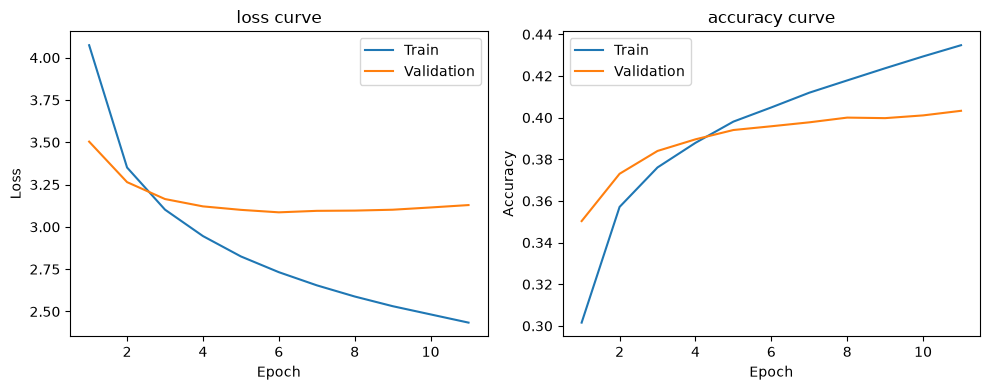

In [169]:
Learning_rate = 0.001
Weight_decay = 0.01
Epochs = 20

caption_model = quiz4.CaptionModel(vocab_size=len(vocab)).to(device)
criterion = torch.nn.CrossEntropyLoss(ignore_index=vocab["<PAD>"])
optimizer = torch.optim.AdamW(caption_model.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
patience = 5
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz4.train_one_epoch(caption_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = quiz4.evaluate(caption_model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1} | "
        f"train loss {train_loss:.4f}, token acc {train_acc:.4f} | "
        f"val loss {val_loss:.4f}, token acc {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        
        torch.save({
            "model_state_dict": caption_model.state_dict(),
            "vocab": vocab,
        }, "./checkpoints/caption_model_best.pt")
        
        print("已保存最佳模型")

    else:
        epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Validation loss 連續 5 輪沒有改善，停止訓練。")
            break
        
quiz4.plot_history(history, result_path="./results/caption_model")

In [170]:
checkpoint = torch.load("./checkpoints/caption_model_best.pt", map_location=device, weights_only=True)
caption_model.load_state_dict(checkpoint["model_state_dict"])
vocab = checkpoint["vocab"]

caption_model.eval()

CaptionModel(
  (encoder): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=192, out_features=576, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=192, out_features=768, bias=True)
          (a